In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import sys
sys.path.insert(0, str(Path("..").resolve()))

from environment.retail_env import RetailEnv
from agents.dqn.dqn_agent import DQNAgent
from agents.ppo.ppo_agent import PPOAgent
from agents.a2c.a2c_agent import A2CAgent
from agents.qtable.qtable_agent import QTableAgent
from agents.baselines.baseline_agents import RandomAgent, FixedMarginAgent, AlwaysCheapestAgent
from utils.trainer import Trainer

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 5)
print("Ready")

Ready


In [2]:
N_EPISODES = 50
CUSTOMERS  = 500   # reduced for speed, still meaningful

env = RetailEnv()
env.demand.base_daily_customers = CUSTOMERS

dqn_cfg  = {'lr': 1e-4, 'gamma': 0.99, 'batch_size': 128,
             'min_buffer': 200, 'epsilon_decay': 5000,
             'buffer_size': 20000}
ppo_cfg  = {'lr': 3e-4, 'gamma': 0.99, 'rollout_len': 50,
             'batch_size': 25, 'n_epochs': 3, 'clip_eps': 0.2}
a2c_cfg  = {'lr': 7e-4, 'gamma': 0.99, 'n_steps': 10}
qtab_cfg = {'lr': 0.1,  'gamma': 0.99, 'epsilon_decay': 3000}

agents = {
    'walmart':      DQNAgent(0,  'walmart',      266, 50, 'pure_revenue',            dqn_cfg,  seed=42),
    'target':       PPOAgent(1,  'target',        266, 50, 'profit_margin',           ppo_cfg,  seed=42),
    'amazon_fresh': A2CAgent(2,  'amazon_fresh',  266, 50, 'market_share',            a2c_cfg,  seed=42),
    'qfc':          QTableAgent(3,'qfc',           266, 50, 'revenue_with_inventory',  qtab_cfg, seed=42),
    'safeway':      RandomAgent(4,  'safeway',      50),
    'kroger':       RandomAgent(5,  'kroger',       50),
    'trader_joes':  FixedMarginAgent(6,  'trader_joes',  50),
    'whole_foods':  FixedMarginAgent(7,  'whole_foods',  50),
    'aldi':         AlwaysCheapestAgent(8, 'aldi',   50),
    'costco':       RandomAgent(9,  'costco',       50),
}

trainer = Trainer(env, agents,
                  checkpoint_dir=Path("../checkpoints"),
                  save_every=10)
print(f"Training {N_EPISODES} episodes × 365 days × {CUSTOMERS} customers")
print(f"RL agents: walmart(DQN), target(PPO), amazon_fresh(A2C), qfc(QTable)")

2026-03-02 00:27:25 | INFO     | environment.demand_model | MNLDemandModel (basket-level) initialized | customers=10000 | price_sensitivity=2.5 | brand_loyalty=0.59 | mean_basket_size=10
2026-03-02 00:27:25 | INFO     | environment.inventory | InventoryManager initialized | agents=10 | products=50 | initial_stock=500 | reorder_point=100
2026-03-02 00:27:25 | INFO     | environment.supply_chain | SupplyChain initialized | lead_time=2-7 days | disruption_prob=0.0001
2026-03-02 00:27:25 | INFO     | environment.promotions | PromotionCalendar initialized | 11 promo windows | weekend_multiplier=1.347
2026-03-02 00:27:25 | INFO     | environment.retail_env | RetailEnv initialized | agents=10 | products=50 | obs_size=266 | episode_length=365
2026-03-02 00:27:25 | INFO     | agents.base_agent.walmart | DQNAgent initialized | id=0 | reward_fn=pure_revenue
2026-03-02 00:27:25 | INFO     | agents.base_agent.walmart | DQNAgent initialized | id=0 | reward_fn=pure_revenue
2026-03-02 00:27:26 | INFO 

In [3]:
import time

start = time.time()
results = []

for episode in range(N_EPISODES):
    ep_start = time.time()
    ep_results = trainer.train(n_episodes=1)
    results.extend(ep_results)
    ep_time = time.time() - ep_start
    elapsed = time.time() - start

    r = ep_results[0]
    top = sorted(r.revenues.items(), key=lambda x: x[1], reverse=True)[:3]
    top_str = ", ".join([f"{n}(${v:,.0f})" for n, v in top])

    rl_revs = {n: r.revenues.get(n, 0)
               for n in ['walmart','target','amazon_fresh','qfc']}
    rl_str = " | ".join([f"{n[:3]}=${v:,.0f}" for n, v in rl_revs.items()])

    eta = (elapsed / (episode + 1)) * (N_EPISODES - episode - 1)
    print(
        f"Ep {episode+1:>2}/{N_EPISODES} "
        f"[{ep_time:.1f}s, ETA {eta:.0f}s] "
        f"Top: {top_str}"
    )
    print(f"         RL: {rl_str}")

total = time.time() - start
print(f"\nDone! {total:.1f}s total ({total/N_EPISODES:.1f}s/episode)")

# verify RL agents are actually learning
from agents.dqn.dqn_agent import DQNAgent
from agents.qtable.qtable_agent import QTableAgent

walmart = agents['walmart']
qfc     = agents['qfc']

print(f"\nLearning verification:")
print(f"  DQN epsilon:      {walmart.epsilon:.4f} (should be < 1.0)")
print(f"  DQN buffer size:  {len(walmart.buffer)} (should be > 0)")
print(f"  DQN total steps:  {walmart.total_steps}")
print(f"  QTable states:    {len(qfc.q_table)}")
print(f"  QTable epsilon:   {qfc.epsilon:.4f}")

Ep  1/50 [7.3s, ETA 360s] Top: aldi($1,875,489), qfc($1,453,815), whole_foods($1,345,175)
         RL: wal=$1,103,226 | tar=$1,172,918 | ama=$162,080 | qfc=$1,453,815
Ep  2/50 [7.6s, ETA 360s] Top: aldi($1,875,489), qfc($1,453,815), whole_foods($1,345,175)
         RL: wal=$1,103,226 | tar=$1,172,918 | ama=$162,080 | qfc=$1,453,815
Ep  3/50 [7.8s, ETA 357s] Top: aldi($1,875,489), qfc($1,453,815), whole_foods($1,345,175)
         RL: wal=$1,103,226 | tar=$1,172,918 | ama=$162,080 | qfc=$1,453,815
Ep  4/50 [7.7s, ETA 350s] Top: aldi($1,875,489), qfc($1,453,815), whole_foods($1,345,175)
         RL: wal=$1,103,226 | tar=$1,172,918 | ama=$162,080 | qfc=$1,453,815
Ep  5/50 [7.7s, ETA 344s] Top: aldi($1,875,489), qfc($1,453,815), whole_foods($1,345,175)
         RL: wal=$1,103,226 | tar=$1,172,918 | ama=$162,080 | qfc=$1,453,815
Ep  6/50 [7.8s, ETA 337s] Top: aldi($1,875,489), qfc($1,453,815), whole_foods($1,345,175)
         RL: wal=$1,103,226 | tar=$1,172,918 | ama=$162,080 | qfc=$1,453,81

In [5]:
rows = []
for r in results:
    for agent_name in agents:
        rows.append({
            'episode':       r.episode,
            'agent':         agent_name,
            'revenue':       r.revenues.get(agent_name, 0),
            'market_share':  r.market_shares.get(agent_name, 0),
            'reward':        r.total_rewards.get(agent_name, 0),
            'agent_type':    ('RL' if agent_name in
                             ['walmart','target','amazon_fresh','qfc']
                             else 'Rule-Based'),
        })

df = pd.DataFrame(rows)
print(df.groupby(['agent','agent_type'])['revenue'].mean().sort_values(ascending=False).round(0))

agent         agent_type
aldi          Rule-Based    2457095.0
whole_foods   Rule-Based    1767705.0
trader_joes   Rule-Based    1744904.0
target        RL            1418023.0
costco        Rule-Based    1406995.0
safeway       Rule-Based    1404845.0
kroger        Rule-Based    1372858.0
qfc           RL             323960.0
walmart       RL             236974.0
amazon_fresh  RL              59887.0
Name: revenue, dtype: float64


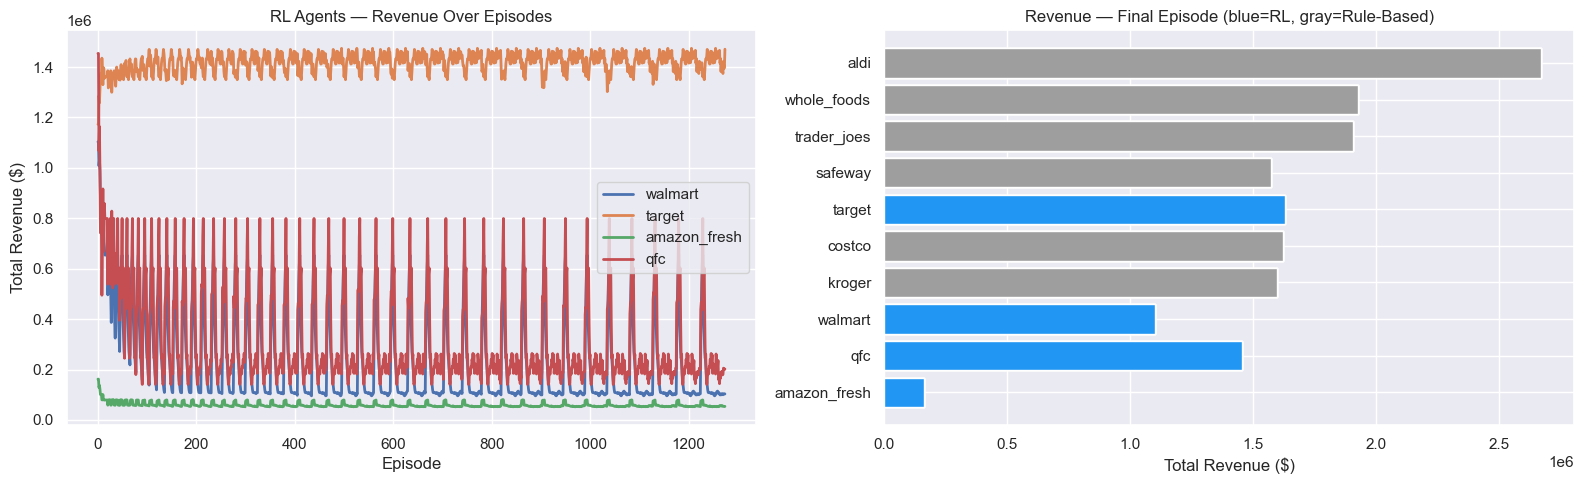

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# RL agents
ax = axes[0]
rl_agents = ['walmart', 'target', 'amazon_fresh', 'qfc']
for agent in rl_agents:
    d = df[df['agent']==agent]['revenue']
    smoothed = d.rolling(5, min_periods=1).mean()
    ax.plot(range(len(d)), smoothed, label=agent, linewidth=2)
ax.set_title("RL Agents — Revenue Over Episodes", fontsize=12)
ax.set_xlabel("Episode")
ax.set_ylabel("Total Revenue ($)")
ax.legend()

# All agents final episode
ax = axes[1]
final = df[df['episode']==df['episode'].max()]
final_sorted = final.sort_values('revenue', ascending=True)
colors = ['#2196F3' if t=='RL' else '#9E9E9E'
          for t in final_sorted['agent_type']]
ax.barh(final_sorted['agent'], final_sorted['revenue'], color=colors)
ax.set_title(f"Revenue — Final Episode (blue=RL, gray=Rule-Based)", fontsize=12)
ax.set_xlabel("Total Revenue ($)")

plt.tight_layout()
plt.savefig("../docs/training_revenue.png", dpi=150)
plt.show()

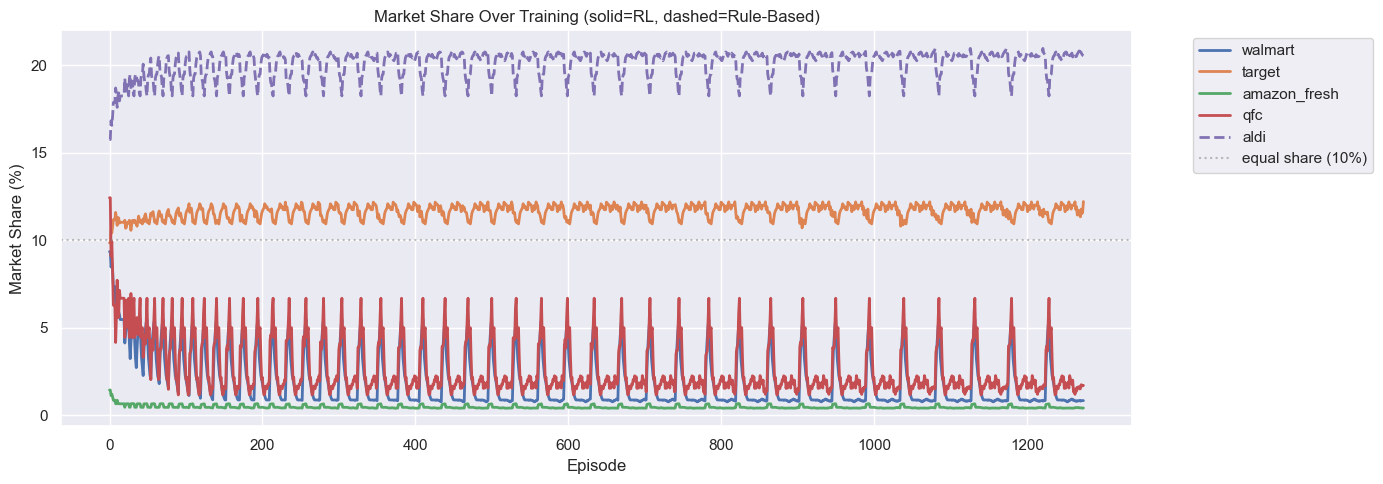

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
for agent in ['walmart', 'target', 'amazon_fresh', 'qfc', 'aldi']:
    d = df[df['agent']==agent]['market_share'] * 100
    smoothed = d.rolling(5, min_periods=1).mean()
    style = '-' if agent in rl_agents else '--'
    ax.plot(range(len(d)), smoothed, label=agent,
            linewidth=2, linestyle=style)

ax.axhline(10, color='gray', linestyle=':', alpha=0.5, label='equal share (10%)')
ax.set_title("Market Share Over Training (solid=RL, dashed=Rule-Based)", fontsize=12)
ax.set_xlabel("Episode")
ax.set_ylabel("Market Share (%)")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../docs/training_market_share.png", dpi=150)
plt.show()

In [11]:
print("=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"Episodes trained: {N_EPISODES}")
print(f"Days per episode: 365")
print(f"Customers/day:    {CUSTOMERS}")
print()

# use results list directly — it has one entry per episode
first5_results = results[:5]
last5_results  = results[-5:]

def avg_revenue(result_list, agent_name):
    return np.mean([r.revenues.get(agent_name, 0) for r in result_list])

print(f"{'Agent':<15} {'Avg Rev (ep1-5)':>16} {'Avg Rev (last 5)':>17} {'Change':>10}")
print("-" * 62)
for agent in ['walmart','target','amazon_fresh','qfc','aldi','random_avg']:
    if agent == 'random_avg':
        r1 = np.mean([avg_revenue(first5_results, n) for n in ['safeway','kroger','costco']])
        r2 = np.mean([avg_revenue(last5_results,  n) for n in ['safeway','kroger','costco']])
        name = 'random (avg)'
    else:
        r1   = avg_revenue(first5_results, agent)
        r2   = avg_revenue(last5_results,  agent)
        name = agent
    change = ((r2 - r1) / r1 * 100) if r1 > 0 else 0
    marker = '↑' if change > 5 else ('↓' if change < -5 else '→')
    print(f"{name:<15} ${r1:>14,.0f}   ${r2:>14,.0f}   {marker}{abs(change):>6.1f}%")
print("=" * 60)

TRAINING SUMMARY
Episodes trained: 50
Days per episode: 365
Customers/day:    500

Agent            Avg Rev (ep1-5)  Avg Rev (last 5)     Change
--------------------------------------------------------------
walmart         $       988,939   $       103,323   ↓  89.6%
target          $     1,308,633   $     1,470,556   ↑  12.4%
amazon_fresh    $       122,084   $        53,980   ↓  55.8%
qfc             $       989,403   $       202,101   ↓  79.6%
aldi            $     2,073,380   $     2,480,536   ↑  19.6%
random (avg)    $     1,211,719   $     1,408,058   ↑  16.2%
